In [80]:
#student_name = "Iman Dashtpeyma"
#student_id = "imda3139"
#student_background = "Software developer, Network security, and DevOps "

# Student Alcohol Consumption Dataset Analysis

## 1. Dataset Source
Source: https://www.kaggle.com/datasets/uciml/student-alcohol-consumption/data

## 2. Domain Area
The dataset was collected from two secondary schools in Portugal through school reports. It aims to understand the relationship between students' social, demographic, and school-related features with their academic performance and alcohol consumption patterns. The data was gathered to analyze factors affecting student achievement in secondary education.

## 3. Data File Structure
The dataset consists of two separate .csv files (student-mat.csv and student-por.csv) for Mathematics and Portuguese language students respectively.

## 4. Features and Observations
- Mathematics dataset: 395 observations
- Portuguese dataset: 649 observations
- Total features: 33 variables per dataset

## 5. Numerical Features (8 features)
- age
- Medu, Fedu: Mother's and Father's education 
- failures: Past class failures
- absences: Number of school absences
- G1, G2, G3: Grades
- Dalc, Walc: Workday/Weekend alcohol consumption 

## 6. Categorical Features (15 features)
Nominal:
- school: 'GP' or 'MS'
- Mjob, Fjob: Mother's/Father's job
- reason: Reason to choose school
- guardian: Student's guardian

Ordinal:
- traveltime: Home to school travel time
- studytime: Weekly study time
- famrel: Quality of family relationships
- freetime: Free time after school
- goout: Going out with friends

## 7. Binary Features (8 features)
- sex: 'F' or 'M'
- address: 'U' (urban) or 'R' (rural)
- famsize: 'LE3' or 'GT3'
- Pstatus: 'T' or 'A'
- schoolsup: 'yes' or 'no'
- famsup: 'yes' or 'no'
- paid: 'yes' or 'no'
- internet: 'yes' or 'no'

**Info** datasets will be stored in the Folder named "Data." Be sure all library is installed, especially Pandas, Seaborn, Matplotlib.

**2 datasets combined in one file with extra columns named course**

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
#fixing the graph issue in Jupyter Notebook
#%matplotlib inline
import pandas as pd

# Load  two  datasets
math_df = pd.read_csv("./Data/student-mat.csv")
portuguese_df = pd.read_csv("./Data/student-por.csv")

# Add a new column 'course' to each dataset
math_df['course'] = 'mat'
portuguese_df['course'] = 'por'

# Combine the two datasets
combined_df = pd.concat([math_df, portuguese_df])

# Save the combined dataset to a new CSV file in Data folder
combined_df.to_csv("./Data/combined_student_data.csv", index=False)

print("Combined dataset saved as 'combined_student_data.csv'")

Combined dataset saved as 'combined_student_data.csv'


**which type each column belongs?**

In [82]:
print("Data types of each column in the combined dataset:")
combined_df.dtypes

Data types of each column in the combined dataset:


school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
course        object
dtype: object

**What is the total size  and head of the dataset?**

In [83]:
print(combined_df.shape)
combined_df.head()

(1044, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,mat
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,mat
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,mat
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,mat
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,mat


**Read the data**

In [84]:

data = pd.read_csv('./Data/combined_student_data.csv')

# Display the first few rows of the dataset
print("First few rows of the dataset:")
data.head()

First few rows of the dataset:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,mat
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,mat
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,mat
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,mat
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,mat


## Initial EDA
**Data Types**: After loading the data, numerical features like `age`, `absences`, and grades (`G1`, `G2`, `G3`) were identified. Categorical features like `school`, `sex`, and `guardian` were converted to the correct types.
**Missing Values**: I checked for missing values and handled them appropriately. No major gaps were found in essential features.

### Univariate Q1: How many students reported high weekend alcohol consumption (Walc > 3)?

In [85]:
# Count how many students have Walc (weekend alcohol consumption) greater than 3
high_walc_count = combined_df[combined_df['Walc'] > 3].shape[0]
print(f"Number of students with high weekend alcohol consumption (Walc > 3): {high_walc_count}")


Number of students with high weekend alcohol consumption (Walc > 3): 211


**Reflection** :This analysis reveals how many students engage in high levels of alcohol consumption during weekends. Weekend drinking is often social and may impact study habits and academic performance. By identifying the count of students in this group, we can explore further if this behavior correlates with lower grades, attendance issues, or other academic challenges

###  Univariate Q2: What is the mean final grade (G3)?

In [86]:
# Calculate the mean of the final grade
mean_final_grade = combined_df['G3'].mean()
print(f"Mean final grade (G3): {mean_final_grade:.2f}")

Mean final grade (G3): 11.34


**Reflaction** : The mean final grade (G3) is 11.34, which indicates that most students are performing slightly above the midpoint of the grading scale.
This suggests that the overall academic performance in the dataset is relatively stable and satisfactory. The average can serve as a useful reference point when analyzing specific groups or behaviors (e.g., comparing students with high vs. low study time or alcohol consumption)

### Bivariate Q1: Which gender consumes more alcohol on average (workdays and weekends)?

         Dalc      Walc
sex                    
F    1.274112  1.944162
M    1.781457  2.728477


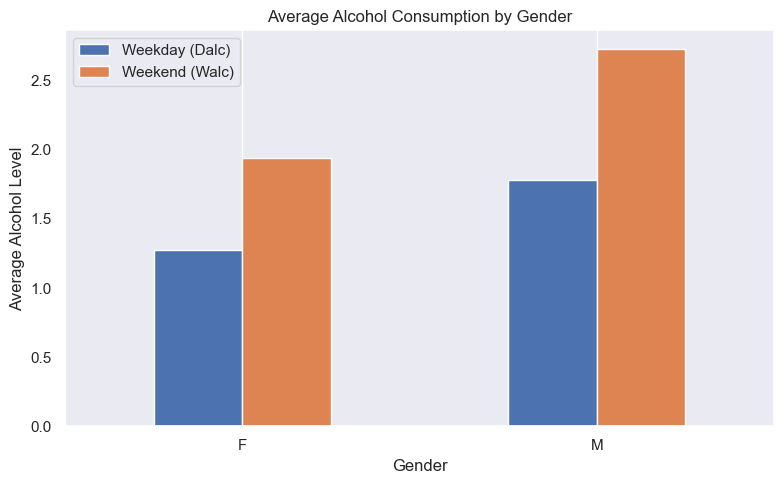

In [87]:
avg_alcohol_by_gender = combined_df.groupby('sex')[['Dalc', 'Walc']].mean()
print(avg_alcohol_by_gender)
# Plotting the results
avg_alcohol_by_gender.plot(kind='bar', figsize=(8, 5))
plt.title('Average Alcohol Consumption by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Alcohol Level')
plt.legend(['Weekday (Dalc)', 'Weekend (Walc)'])
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


**Reflection** The results show that male students consume more alcohol than female students on both weekdays and weekends.
On average, males scored 1.78 for weekday drinking (Dalc) and 2.73 for weekend drinking (Walc),
while females scored 1.27 and 1.94, respectively.
This suggests that male students tend to engage more frequently in alcohol consumption, particularly over the weekend. These behavioral differences may reflect varying social patterns or coping mechanisms and could have implications for academic outcomes or health-focused interventions.

###  Bivariate Q2: What is the average final grade by gender?

In [88]:
# Calculate the average final grade for each gender
avg_grade_by_gender = combined_df.groupby('sex')['G3'].mean()
print(avg_grade_by_gender)


sex
F    11.448393
M    11.203091
Name: G3, dtype: float64


**Reflection**: The average final grade for female students is 11.45, slightly higher than male students at 11.20.
Although the difference is small, it suggests that female students tend to perform marginally better

### Bivariate Q3: What are the average final grades by alcohol consumption levels (Dalc and Walc)?

In [89]:
# Calculate average final grade grouped by weekday and weekend alcohol consumption levels
avg_grade_by_dalc = combined_df.groupby('Dalc')['G3'].mean()
avg_grade_by_walc = combined_df.groupby('Walc')['G3'].mean()

# Display results
print("Average Final Grades by Weekday Alcohol Consumption (Dalc):")
print(avg_grade_by_dalc)

print("\nAverage Final Grades by Weekend Alcohol Consumption (Walc):")
print(avg_grade_by_walc)


Average Final Grades by Weekday Alcohol Consumption (Dalc):
Dalc
1    11.704264
2    10.556122
3    10.898551
4     9.269231
5    10.384615
Name: G3, dtype: float64

Average Final Grades by Weekend Alcohol Consumption (Walc):
Walc
1    11.743719
2    11.472340
3    11.290000
4    10.536232
5    10.397260
Name: G3, dtype: float64


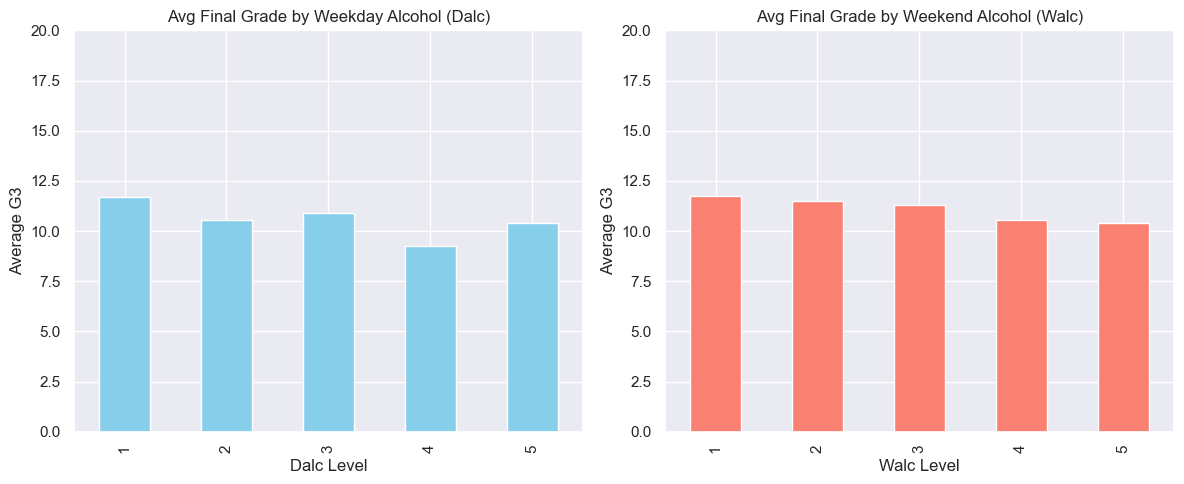

In [90]:
# Plot average grades by alcohol levels
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

avg_grade_by_dalc.plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('Avg Final Grade by Weekday Alcohol (Dalc)')
ax[0].set_xlabel('Dalc Level')
ax[0].set_ylabel('Average G3')
ax[0].set_ylim(0, 20)

avg_grade_by_walc.plot(kind='bar', ax=ax[1], color='salmon')
ax[1].set_title('Avg Final Grade by Weekend Alcohol (Walc)')
ax[1].set_xlabel('Walc Level')
ax[1].set_ylabel('Average G3')
ax[1].set_ylim(0, 20)

plt.tight_layout()
plt.show()


**Reflection**  :The data shows a clear negative trend between alcohol consumption and academic performance.
For weekday drinking (Dalc), the average grade drops from 11.70 at level 1 to 9.27 at level 4.
For weekend drinking (Walc), grades decrease from 11.74 at level 1 to 10.40 at level 5.
This suggests that higher alcohol consumption especially during the week has a noticeable impact on student performance. The decline is more pronounced with weekday drinking, possibly because it directly interferes with school activities, concentration, and study time.

### Bivariate Q4: What is the average number of absences by weekend alcohol consumption level (Walc)?

In [91]:
# Group by Walc level and calculate the average number of absences
avg_absences_by_walc = combined_df.groupby('Walc')['absences'].mean()
print(avg_absences_by_walc)

Walc
1    3.635678
2    4.012766
3    4.910000
4    6.007246
5    5.876712
Name: absences, dtype: float64


**Reflection** :The results show a clear upward trend: students who drink more on weekends tend to have more absences.
For example, students with the lowest Walc level (1) have an average of 3.6 absences, while those at level 4 average 6.0 absences. This suggests that increased weekend alcohol consumption is associated with reduced class attendance, possibly due to fatigue, hangovers, or lifestyle habits that disrupt academic routines.

 ### Correlation Q1: What is the correlation between study time and final grade (G3)?

In [92]:
# Correlation between study time and final grade
corr_study_g3 = combined_df['studytime'].corr(combined_df['G3'])
print(f"Correlation between study time and final grade (G3): {corr_study_g3:.2f}")


Correlation between study time and final grade (G3): 0.16


**ReflectionThe** : correlation between study time and final grade (G3) is 0.16, which indicates a weak positive relationship.
This means that students who study more tend to achieve slightly better final grade

### Correlation Q2:  What is the correlation between study time and alcohol consumption (weekday and weekend)?

In [93]:
# Correlation between study time and weekday alcohol consumption (Dalc)
corr_study_dalc = combined_df['studytime'].corr(combined_df['Dalc'])
print(f"Correlation between study time and Dalc (weekday drinking): {corr_study_dalc:.2f}")

# Correlation between study time and weekend alcohol consumption (Walc)
corr_study_walc = combined_df['studytime'].corr(combined_df['Walc'])
print(f"Correlation between study time and Walc (weekend drinking): {corr_study_walc:.2f}")


Correlation between study time and Dalc (weekday drinking): -0.16
Correlation between study time and Walc (weekend drinking): -0.23


**Reflection**The correlation between study time and weekday alcohol consumption (Dalc) is -0.16, and with weekend consumption (Walc) is -0.23.
Both are weak negative correlations, suggesting that students who study more tend to drink slightly less especially on weekends.